In [1]:
import pandas as pd
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
data_ref = 'C:/Users/gerso/FBR/predictive/tatoeba-de-en/data/raw/comet/train_predictive_ancestral_scores_100_1000.parquet'

In [3]:
df = pd.read_parquet(data_ref)

In [4]:
print(df["utilities"][0])

[array([ 0.9974552 ,  0.7887466 ,  0.7296187 ,  0.8248366 ,  0.8245211 ,
         0.799813  ,  0.73866934,  0.8273732 ,  0.8346483 ,  0.76152825,
         0.7241546 ,  0.73906016, -0.72761947,  0.69963926,  0.64665586,
         0.2938656 ,  0.7099144 ,  0.57816887,  0.7602806 , -0.85019565,
         0.8577156 , -0.25303409,  0.608438  ,  0.7951963 ,  0.7253987 ,
         0.71772945, -1.3348169 ,  0.76853335,  0.64123523], dtype=float32)
 array([ 0.774308  ,  0.6554523 ,  0.6652514 ,  0.89047545,  0.71440864,
         0.74400353,  0.6890213 ,  0.7447629 ,  0.6619603 ,  0.92144555,
         0.771261  ,  0.6283617 , -0.96044713,  0.611793  ,  0.5750874 ,
         0.5547415 ,  0.5293816 ,  0.28048056,  0.7055052 , -0.8900244 ,
         0.766555  , -0.31004143,  0.36067832,  0.69977146,  0.6063743 ,
         0.9088341 , -1.4270089 ,  0.62598634,  0.7838442 ], dtype=float32)
 array([ 0.87163013,  0.8145732 ,  0.6756834 ,  0.7931426 ,  0.964936  ,
         0.73211086,  0.7747639 ,  0.7492836 

In [5]:
import numpy as np
def get_max(x):
    maxes = []
    for utils in x["utilities"]:
        maxes.append(np.max(utils))
    
    return np.max(utils)

df["max_util"] = df.apply(get_max, axis=1)

In [6]:
def get_min(x):
    maxes = []
    for utils in x["utilities"]:
        maxes.append(np.min(utils))
    
    return np.min(utils)

df["min_util"] = df.apply(get_min, axis=1)

In [7]:
df["max_util"].max()

1.414037

In [8]:
df["min_util"].min()

-2.4226925

In [9]:
from utilities.factories.PreprocessFactory import PreprocessFactory
# Next we preprocess the data
preprocess_factory = PreprocessFactory({
    "name": "basic"
})

preprocessor = preprocess_factory.get_preprocessor()


C:\Users\gerso\anaconda3\envs\thesis\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
df = preprocessor(df)

In [11]:
df["utility"].describe()

count     827603.000000
unique    827600.000000
top           -1.298399
freq           2.000000
Name: utility, dtype: float64

In [12]:
print(df["utility"].min())
print(df["utility"].max())
print(df["utility"].mean())

-1.944098091006279
1.3399425808787346
-0.37572069986192186


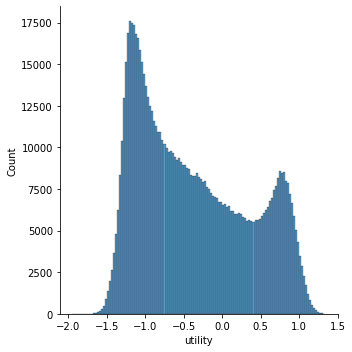

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.displot(data=df, x="utility")


In [14]:
from sklearn import preprocessing

In [19]:
scaler = preprocessing.StandardScaler().fit(np.array(df["utility"].to_list()).reshape(-1, 1))

In [21]:
df["utility_scaled"] = scaler.transform(np.array(df["utility"].to_list()).reshape(-1, 1)).reshape(-1)

In [23]:
df["utility_scaled"].describe()

count    8.276030e+05
mean     2.616017e-16
std      1.000001e+00
min     -2.180250e+00
25%     -8.926068e-01
50%     -1.950801e-01
75%      8.260679e-01
max      2.384997e+00
Name: utility_scaled, dtype: float64

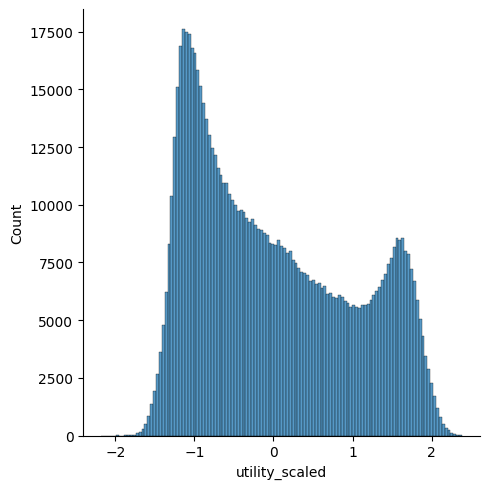

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.displot(data=df, x="utility_scaled")